# HR Attration Analysis 

##### HR Attrition Analysis helps identify the key factors causing employees to leave the organization.
It provides data-driven insights to improve employee retention, satisfaction, and overall workforce performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
df=pd.read_csv(r"C:\Users\BAPS\OneDrive\Documents\PROJECT\HR\HR Dataset CSV.csv")
df.head()

,EmployeeID,Gender,Age,MaritalStatus,EducationLevel,Department,JobRole,JobLevel,BusinessTravel,EmploymentType,...,TeamSize,Attrition,DistanceFromHome,HealthIssues,JobInvolvement,StressLevel,HiringSource,CostToHire,ReplacementCost,Region
0,1,Male,28,Single,High School,HR,Analyst,3,Non-Travel,Contract,...,8,No,29,No,1,1,Campus,35658,38431,West
1,2,Female,23,Single,Master,Marketing,Manager,2,Travel_Rarely,Contract,...,4,No,6,No,2,4,Referral,19692,65758,South
2,3,Female,56,Married,Master,Operations,Specialist,1,Travel_Frequently,Contract,...,3,No,8,Yes,3,1,Campus,48660,23561,East
3,4,Male,29,Married,High School,Operations,Team Lead,3,Travel_Frequently,Full-Time,...,12,No,10,No,1,3,Campus,32403,38141,North
4,5,Male,49,Single,PhD,IT,Analyst,4,Travel_Frequently,Contract,...,11,No,27,No,1,4,LinkedIn,19474,78053,West


In [4]:
df.shape

(1000, 41)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 41 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               1000 non-null   int64  
 1   Gender                   1000 non-null   object 
 2   Age                      1000 non-null   int64  
 3   MaritalStatus            1000 non-null   object 
 4   EducationLevel           1000 non-null   object 
 5   Department               1000 non-null   object 
 6   JobRole                  1000 non-null   object 
 7   JobLevel                 1000 non-null   int64  
 8   BusinessTravel           1000 non-null   object 
 9   EmploymentType           1000 non-null   object 
 10  WorkLocation             1000 non-null   object 
 11  RemoteWork               1000 non-null   object 
 12  DateOfJoining            1000 non-null   object 
 13  YearsAtCompany           1000 non-null   float64
 14  YearsInCurrentRole       

In [6]:
df.isnull().sum()

EmployeeID                 0
Gender                     0
Age                        0
MaritalStatus              0
EducationLevel             0
Department                 0
JobRole                    0
JobLevel                   0
BusinessTravel             0
EmploymentType             0
WorkLocation               0
RemoteWork                 0
DateOfJoining              0
YearsAtCompany             0
YearsInCurrentRole         0
YearsWithCurrentManager    0
MonthlyIncome              0
AnnualSalary               0
SalaryHikePercent          0
Bonus                      0
StockOptionLevel           0
OverTime                   0
PerformanceRating          0
JobSatisfaction            0
EnvironmentSatisfaction    0
WorkLifeBalance            0
NumberOfProjects           0
PromotionInLast5Years      0
EngagementScore            0
AbsenteeismDays            0
ManagerRating              0
TeamSize                   0
Attrition                  0
DistanceFromHome           0
HealthIssues  

### Age Group Creation

In [ ]:
bins = [18, 25, 35, 45, 55, 65]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64"]

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df[['Age', 'AgeGroup']].head()

In [51]:
df['AgeGroup'].value_counts()

AgeGroup
25-34    262
45-54    255
35-44    252
55-64    119
18-24    112
Name: count, dtype: int64

### Exploretory Data Analysis(EDA)

In [58]:
total_employees = df.shape[0]
avg_salary = df['AnnualSalary'].mean()
max_salary = df['AnnualSalary'].max()
min_salary = df['AnnualSalary'].min()

print("Total Employees:", total_employees)
print("Average AnnualSalary:", round(avg_salary,2))
print("Highest AnnualSalary:", max_salary)
print("Lowest AnnualSalary:", min_salary)

Total Employees: 1000
Average AnnualSalary: 1032295.62
Highest AnnualSalary: 1797888
Lowest AnnualSalary: 240888


### 1. Age Distribution

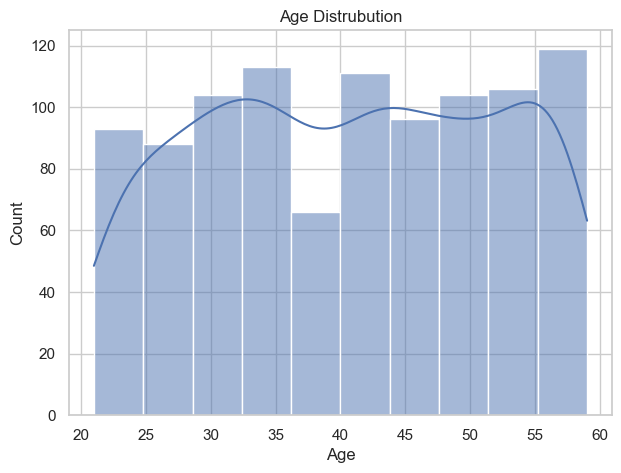

In [52]:
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Age Distrubution')
plt.show()

##### Insights: 
- Majority of employees fall within mid-age range.
- Workforce appears concentrated in working-age population, which may impact tenure and attrition patterns.

### 2. Employee By AgeGroup

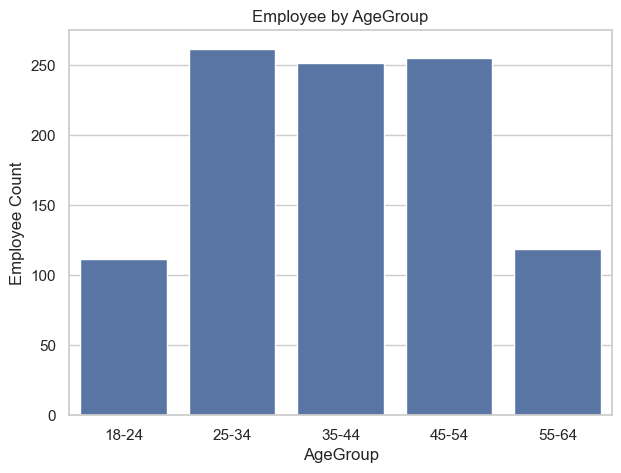

In [53]:
plt.figure(figsize=(7,5))
sns.countplot(x='AgeGroup', data=df)
plt.title("Employee by AgeGroup")
plt.ylabel("Employee Count")
plt.show()

##### Insights:
- Certain age groups dominate the workforce.
- Younger age groups may require deeper attrition analysis.

### 3. Gender Distribution

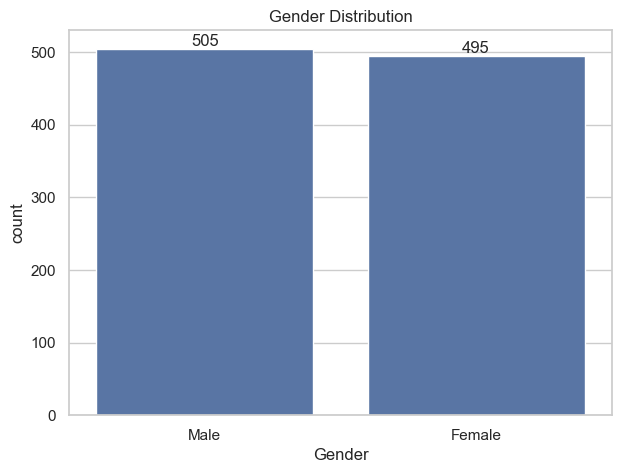

In [54]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', 
        va='bottom')
plt.show()

##### Insights:
- Workforce gender balance is visible.
- If imbalance exists, attrition comparison by gender becomes important.

### 4. Salary Distribution

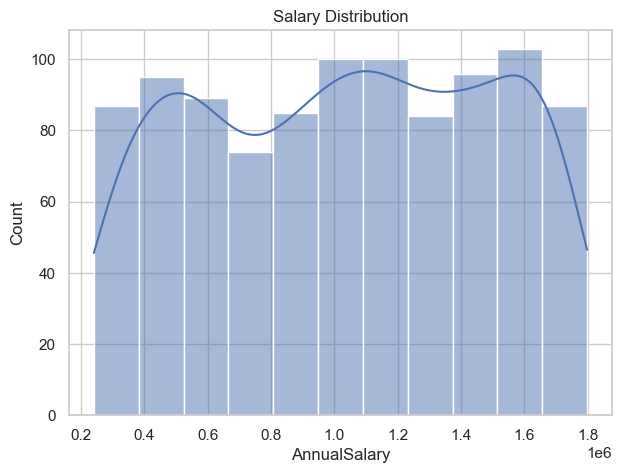

In [55]:
plt.figure(figsize=(7,5))
sns.histplot(x='AnnualSalary', data=df, kde = True)
plt.title('Salary Distribution')
plt.show()

##### Insights
- Salary appears skewed (if right-skewed → few high earners).
- Lower salary concentration may influence attrition.

### 5. Employee By Department

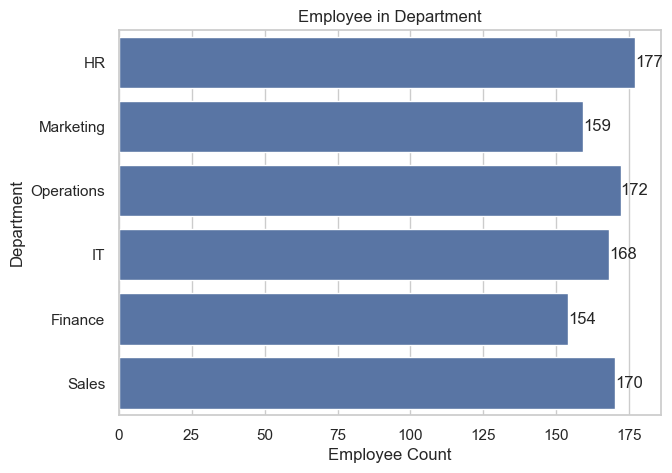

In [56]:
plt.figure(figsize=(7,5))
ax = sns.countplot(y='Department', data=df)
plt.title('Employee in Department')
plt.xlabel('Employee Count')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width())}',   # Get count
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha='left', 
        va='center'
    )

plt.show()

##### Insights:
- Some departments have significantly larger workforce.
- High employee concentration may impact turnover volume.

### 6. Salary By AgeGroup

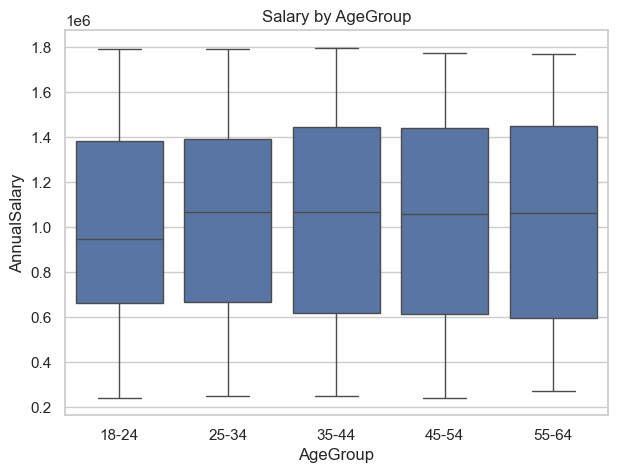

In [57]:
plt.figure(figsize=(7,5))
sns.boxplot(x='AgeGroup', y='AnnualSalary',  data=df)
plt.title('Salary by AgeGroup')
plt.show()

##### Insights:
- Older age groups generally earn higher salaries.
- Salary progression appears linked to age/experience.

### 7. Salary By Experience

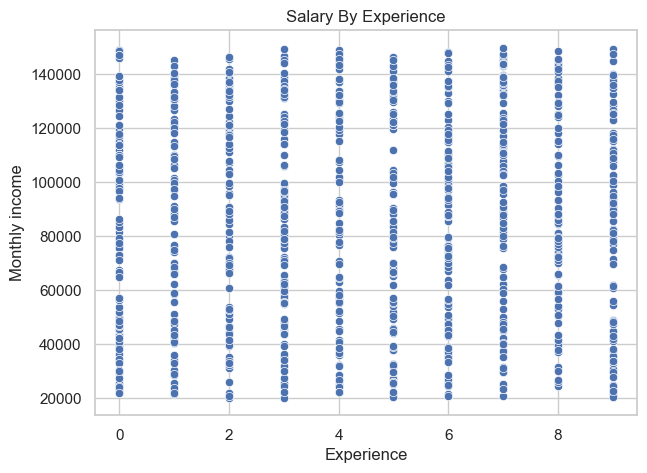

In [65]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='YearsInCurrentRole', y='MonthlyIncome',data= df)
plt.title('Salary By Experience')
plt.xlabel('Experience')
plt.ylabel('Monthly income')
plt.show()

##### Insights:
- Positive trend indicates salary increases with role tenure.
- Outliers may indicate performance-based pay variation.

### Salary By Gender

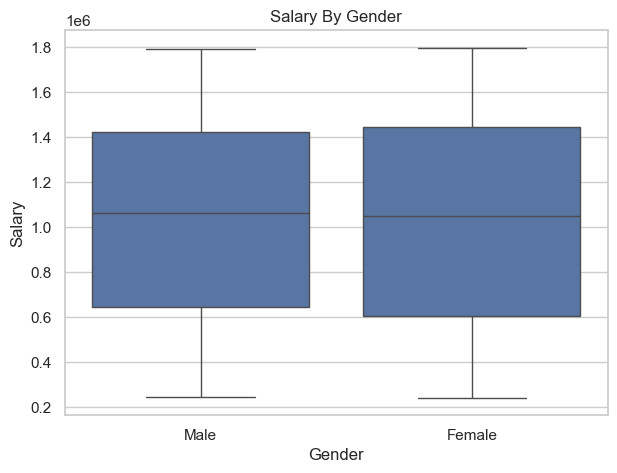

In [74]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Gender', y='AnnualSalary',data=df)
plt.title('Salary By Gender')
plt.ylabel('Salary')
plt.show()

##### Insights:
- Salary differences between genders can be identified.
- Helps evaluate pay equity across workforce.

### 9. Attration Distribution

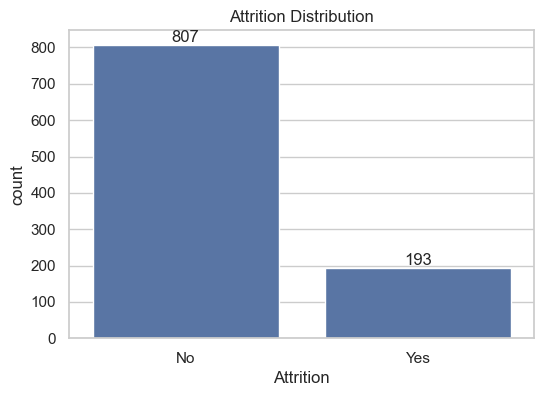

In [77]:
if 'Attrition' in df.columns:
    plt.figure(figsize=(6,4))
    ax = sns.countplot(x='Attrition', data=df)
    
    plt.title("Attrition Distribution")
    
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom')
    
    plt.show()

##### Insights:
- Attrition rate appears imbalanced (likely ~15–20%).
- Indicates moderate turnover risk within organization.

In [19]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

dept_attrition


Attrition,No,Yes
Department,,
Finance,87.662338,12.337662
HR,81.920904,18.079096
IT,78.571429,21.428571
Marketing,83.018868,16.981132
Operations,81.395349,18.604651
Sales,72.352941,27.647059


### 10. Monthly Income VS Attrition

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

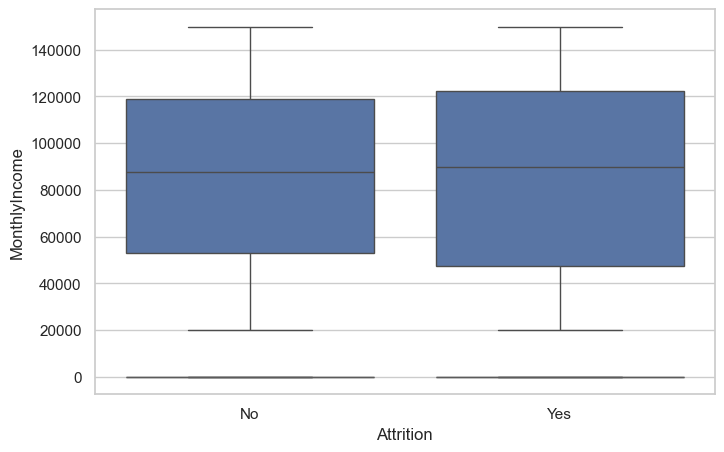

In [8]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)

##### Insights:
- Employees who left may have lower salary levels.
- Shorter tenure employees show higher attrition tendency.

In [11]:
df["Risk_Score"] = (
    (4 - df["JobSatisfaction"]) +
    (4 - df["WorkLifeBalance"]) +
    np.where(df["OverTime"] == "Yes", 2, 0)
)

In [12]:
def risk_category(score):
    if score >= 6:
        return "High Risk"
    elif score >= 3:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Category"] = df["Risk_Score"].apply(risk_category)

In [13]:
df["Risk_Category"].value_counts()

Risk_Category
Medium Risk    545
High Risk      233
Low Risk       222
Name: count, dtype: int64

### Risk Category Distribution

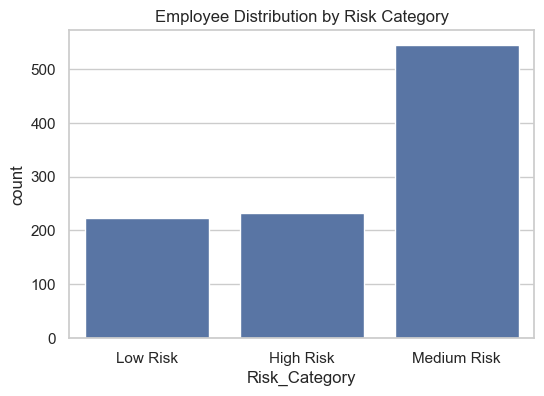

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Risk_Category", data=df)
plt.title("Employee Distribution by Risk Category")
plt.show()

### Insights:
- ignificant portion classified as medium/high risk.
- Supports need for proactive retention strategy.

#### Attrition Rate % BY Risk Category

In [15]:
pd.crosstab(df["Risk_Category"], df["Attrition"], normalize="index") * 100

Attrition,No,Yes
Risk_Category,,
High Risk,79.828326,20.171674
Low Risk,80.180180,19.819820
Medium Risk,81.284404,18.715596


#### Attrition Rate % By Category

In [20]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

dept_attrition

Attrition,No,Yes
Department,,
Finance,87.662338,12.337662
HR,81.920904,18.079096
IT,78.571429,21.428571
Marketing,83.018868,16.981132
Operations,81.395349,18.604651
Sales,72.352941,27.647059


#### Attrition Rate % By OverTime

In [21]:
pd.crosstab(df["OverTime"], df["Attrition"], normalize="index")

Attrition,No,Yes
OverTime,,
No,0.806841,0.193159
Yes,0.807157,0.192843


#### Attrition Rate % BY JobRole

In [22]:
job_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

job_attrition

Attrition,No,Yes
JobRole,,
Analyst,79.581152,20.418848
Executive,79.908676,20.091324
Manager,77.094972,22.905028
Specialist,82.653061,17.346939
Team Lead,83.720930,16.279070


In [26]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     80.7
Yes    19.3
Name: proportion, dtype: float64

In [78]:
df.to_excel("HR DATASET.xlsx", index=False)

## Key Insights:

1. Majority employees fall in the Adult age group.
2. Salary increases with experience.
3. Some departments have higher employee concentration.
4. Gender salary comparison shows variation.
5. Strong correlation between Experience and Salary.

# THANK YOU